# 컴퓨터비전입문 week04
## 이미지 처리 기초 II
### 실습

In [1]:
import wget
wget.download('https://raw.githubusercontent.com/tysep16/CV26_1/refs/heads/main/like_lenna.png', './img/')

'./img//like_lenna.png'

In [ ]:
import cv2
image = cv2.imread('./img/like_lenna.png', cv2.IMREAD_GRAYSCALE)
cv2.imshow('lenna', image)
cv2.waitKey()
cv2.destroyAllWindows()

이미지 타입 출력

In [1]:
import cv2

image = cv2.imread('./img/like_lenna.png', cv2.IMREAD_GRAYSCALE)
print(type(image))

<class 'numpy.ndarray'>


OpenCV로 읽어드린 이미지 파일은 numpy.ndarray 타입 (nd = n-dimensional)

이미지는 numpy 배열이므로 `[height, width, channel]` 형태로 저장

In [2]:
height, width = image.shape
print(f'pixel height: {height}, pixel width: {width}')

pixel height: 1024, pixel width: 1024


#### numpy 인덱싱/슬라이싱으로 채널 분리

In [ ]:
image = cv2.imread('./img/like_lenna.png')

b = image[:, :, 0]
g = image[:, :, 1]
r = image[:, :, 2]

cv2.imshow('b', b)
cv2.imshow('g', g)
cv2.imshow('r', r)

cv2.waitKey()
cv2.destroyAllWindows()

#### `cv2.split(채널 분리)`과 `cv2.merge(채널 병합)`
* 채널 분리: `cv2.split(이미지)`
* 채널 병합: `cv2.merge([채널1, 채널2, ...])`

In [ ]:
import cv2
image = cv2.imread('./img/like_lenna.png')

bs, gs, rs = cv2.split(image) # OpenCV는 BGR
imgMerged = cv2.merge([bs, gs, rs])

cv2.imshow('bs', bs)
cv2.imshow('gs', gs)
cv2.imshow('rs', rs)

cv2.imshow('imgMerged', imgMerged)
cv2.waitKey()
cv2.destroyAllWindows()

#### numpy 함수로 채널 생성 후 병합
* `np.zeros([height, width, channel], dtype=np.uint8)`로 빈 이미지 생성
* dtype=np.uint8은 jpg/png 표준

In [ ]:
import numpy as np

zero = np.zeros([height, width, 1], dtype=np.uint8)
bgz = cv2.merge([b, g, zero])

cv2.imshow('bgz', bgz)
cv2.waitKey()
cv2.destroyAllWindows()

blue, green, zero 이미지를 병합할 경우 red 채널 영역이 제외

#### `cv2.cvtColor()` : 채널을 포함한 색공간 변경

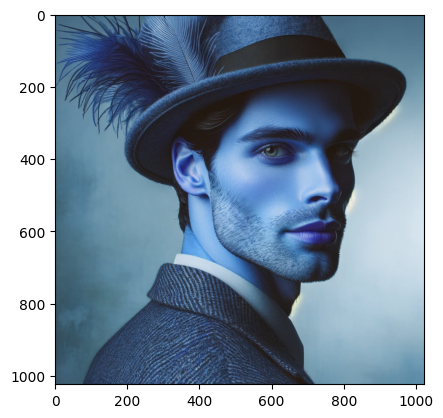

In [1]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread('./img/like_lenna.png')
plt.imshow(image)

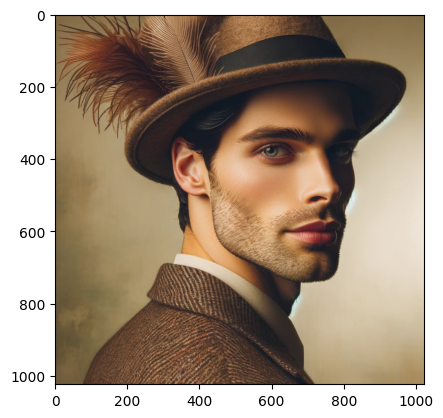

In [3]:
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

RGB로 변환된 image를 BGR로 재변환

In [ ]:
image = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

cv2.imshow('image', image)
cv2.waitKey()
cv2.destroyAllWindows()

BRG에서 GRAY로 변환

In [ ]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cv2.imshow('image', image)
cv2.waitKey()
cv2.destroyAllWindows()

print(image.shape)

(1024, 1024)


: 

#### HSV(Hue, Saturation, Value) 색공간 변환
* 색상(Hue): 0°~360°의 범위 → OpenCV에서는 0~179의 범위
* 채도(Saturation): 0%~100%의 비율로 표현 → OpenCV에서는 0~255의 범위
* 명도(Value): 0%~100%의 비율로 표현 → OpenCV에서는 0~255의 범위

**정리: HSV = ([0~179], [0~255], [0~255])**

In [ ]:
import cv2
image = cv2.imread('./img/like_lenna.png')
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

cv2.imshow('h', h)
cv2.imshow('s', s)
cv2.imshow('v', v)
cv2.waitKey()
cv2.destroyAllWindows()

#### `cv2.inRange()` : 특정 범위 색상 추출
`dst = cv2.inRange(src, lowerb, upperb)`
* 낮은 범위(lowerb)에서 높은 범위(upperb) 사이 = 1, 그 외 = 0으로 치환
* b 채널의 100~255 사이의 값을 전부 255로 치환 = b 채널 강조

In [ ]:
import cv2
image = cv2.imread('./img/like_lenna.png')
b, g, r = cv2.split(image)

b = cv2.inRange(b, 100, 255)
blue = cv2.merge([b, g, r])
cv2.imshow('blue', blue)
cv2.waitKey()
cv2.destroyAllWindows()

#### `cv2.bitwise_and()` : 두 이미지 and 연산
`dst = cv2.bitwise_and(src1, src2, mask)`
* 입력 이미지1(src1)과 입력 이미지2(src2) and 연산 후 마스킹
* b 채널의 어두운 부분은 0으로 마스킹

In [ ]:
import cv2
image = cv2.imread('./img/like_lenna.png')
b, g, r = cv2.split(image)

b = cv2.inRange(b, 100, 255)
filtered = cv2.bitwise_and(image, image, mask=b)

cv2.imshow('filtered', filtered)
cv2.waitKey()
cv2.destroyAllWindows()

#### 이미지 연산

In [ ]:
import cv2
import numpy as np

image = cv2.imread('./img/like_lenna.png')
h, w, c = image.shape
number1 = np.ones([h, w, c], dtype=np.uint8) * 127
number2 = np.ones([h, w, c], dtype=np.uint8) * 2

add = cv2.add(image, number1)
sub = cv2.subtract(image, number1)
mul = cv2.multiply(image, number2)
div = cv2.divide(image, number2)

cv2.imshow('add', add)
cv2.imshow('sub', sub)
cv2.imshow('mul', mul)
cv2.imshow('div', div)
cv2.waitKey()
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np

image = cv2.imread('./img/like_lenna.png')
h, w, c = image.shape
number1 = np.ones([h, w, c], dtype=np.uint8) * 127
number2 = np.ones([h, w, c], dtype=np.uint8) * 2

imgMax = cv2.max(image, number1) # 이미지에서 어두운 부분이 127로 올라가 전체적으로 밝아짐
imgMin = cv2.min(image, number1) # 이미지에서 밝은 부분이 127로 내려가 전체적으로 어두워짐
imgAbs = cv2.absdiff(image, number1) # 절댓값 차이 |픽셀값 - 127| → 127에 가까울수록 어둡고, 멀수록 밝음
imgComp = cv2.compare(image, number1, cv2.CMP_EQ) # 정확히 127인 픽셀만 흰색으로 표시

cv2.imshow('imgMax', imgMax)
cv2.imshow('imgMin', imgMin)
cv2.imshow('imgAbs', imgAbs)
cv2.imshow('imgComp', imgComp)
cv2.waitKey()
cv2.destroyAllWindows()

#### 특정 채널의 특정 범위 출력 (1)

In [ ]:
import wget
import cv2

wget.download('https://raw.githubusercontent.com/tysep16/CV26_1/refs/heads/main/tomato.png', './img/')
image = cv2.imread('./img/tomato.png', cv2.IMREAD_COLOR)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

cv2.imshow('h', h)
cv2.imshow('s', s)
cv2.imshow('v', v)
cv2.waitKey()
cv2.destroyAllWindows()

#### 특정 채널의 특정 범위 출력 (2)
* Hue의 범위를 조정하여 특정 색상의 범위만 출력 = 주황색(h: 8~20)
* 마스킹 기법 사용: `cv2.inRange` → `cv2.bitwise_and`

In [ ]:
import cv2

image = cv2.imread('./img/tomato.png', cv2.IMREAD_COLOR)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

orgMask = cv2.inRange(h, 8, 20)
orange = cv2.bitwise_and(hsv, hsv, mask=orgMask)
orange = cv2.cvtColor(orange, cv2.COLOR_HSV2BGR)

cv2.imshow('orange', orange)
cv2.waitKey()
cv2.destroyAllWindows()

#### 특정 채널 강조

In [ ]:
import cv2
import numpy as np

image = cv2.imread('./img/tomato.png', cv2.IMREAD_COLOR)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

orgMask = cv2.inRange(h, 8, 20)
orange = cv2.bitwise_and(hsv, hsv, mask=orgMask)
orange = cv2.cvtColor(orange, cv2.COLOR_HSV2BGR)

h, w, c = orange.shape
number1 = np.ones([h, w, c], dtype=np.uint8) * 2
mul = cv2.multiply(orange, number1)

cv2.imshow('mul', mul)
cv2.waitKey()
cv2.destroyAllWindows()

### 실습 과제

1. `cv2.cvtColor()` 함수를 이용하여 HSV 색공간으로 변환하고 `cv2.split()` 함수를 이용하여 h, s, v 각각의 채널을 분리하여 출력하세요.

2. 다운받은 이미지 h 채널 값 중 8부터 20까지 범위의 값만 255로, 나머지는 0으로 치환한 후 `cv2.merge()` 함수를 이용하여 모든 채널을 병합한 후 출력하세요.

3. 다운받은 이미지 h 채널 값 중 8부터 20까지의 범위의 값 영역 외의 부분을 마스킹하는 `cv2.bitwise_and()` 함수를 이용하여 출력하세요.